In [16]:
# Check which Python environment is being used
import sys
print(sys.executable)

c:\Users\harit\Desktop\Teaching\BUA340_notes\venv\Scripts\python.exe


In [17]:
# The RD week uses rdrobust (the Calonico-Cattaneo-Titiunik
# estimator). Run this once; if it is already installed pip
# just confirms and moves on.
%pip install rdrobust

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Regression Discontinuity - Main Notebook

Walkthrough notebook for the RD lecture (weeks 7-8), on the **Maimonides class-size data** - the *same running example and same kind of data as the IV week*, now read through the RD lens.

Two files, one generating process:
- **`rd_sharp.csv`** - the 40-student rule is obeyed exactly (sharp RD).
- **`rd_fuzzy.csv`** - ~15% of grades near 40 defy the rule (fuzzy RD = IV at the cutoff).

<div style="background:transparent; padding:10px; border-left:4px solid #1a73e8; border-radius:4px;"><b>This notebook is a reusable template.</b> Every dataset-specific choice lives in <b>one USER INPUTS cell</b> (Section 1.2). Point it at any RD dataset by editing only that cell. (The MLDA practice notebook is just this notebook with that one cell edited.)</div>

## 0. Setup - import the toolkit and load the data

In [19]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import pandas as pd
from rd_toolkit import (
    load_data, set_data_cutoffs, rd_overview_plot, rd_plot, rd_estimate,
    mccrary_test, covariate_balance, bandwidth_sensitivity,
    placebo_cutoffs, fuzzy_rd, rdrobust_compare, summary_table,
)

sharp = load_data('rd_sharp.csv')
# fuzzy = load_data('rd_fuzzy.csv')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded 'rd_sharp.csv': 6000 rows x 9 columns
Columns: ['school_id', 'enrollment', 'threshold', 'predicted_class_size', 'class_size', 'small_class', 'pct_disadvantaged', 'prior_score', 'test_score']

First 5 rows:

 school_id  enrollment  threshold  predicted_class_size  class_size  small_class  pct_disadvantaged  prior_score  test_score
         0          25          0                    25          25            1               58.8        81.95       92.32
         1         111          1                    37          37            0               65.5        71.50       84.52
         2          36          0                    36          36            0               40.7        72.75       88.83
         3          82          1                    27          27            1               35.2        72.27       91.23
         4          43          1                    22          22      

---
## 1. Walkthrough - Maimonides' Rule (class size -> test scores)

<div style="background:transparent; padding:10px; border-left:4px solid #1a73e8; border-radius:4px;"><b>The setup.</b>
<ul>
<li><b>Y</b> = <code>test_score</code></li>
<li><b>D</b> = small class (<code>small_class</code>); the rule splits a grade once enrollment crosses 40</li>
<li><b>R</b> = <code>enrollment</code></li>
<li><b>c</b> = 40 (Maimonides' 40-student cap)</li>
<li><code>predicted_class_size</code> = the sawtooth (the IV week's instrument); here we zoom in on the 40 rung only.</li>
</ul></div>

### 1.1 Look at the data

Each row is one school-grade. `enrollment` runs 20-130 (cutoffs at 40/80/120); RD uses only the rows near 40.

In [ ]:
sharp.describe().round(2) #Summary Statistics 

,school_id,enrollment,threshold,predicted_class_size,class_size,small_class,pct_disadvantaged,prior_score,test_score
count,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00
mean,2999.50,74.58,0.81,31.54,31.54,0.33,44.76,70.11,89.16
std,1732.20,31.66,0.39,5.12,5.12,0.47,13.50,5.90,2.25
min,0.00,20.00,0.00,20.00,20.00,0.00,0.00,47.19,82.51
25%,1499.75,47.00,1.00,28.00,28.00,0.00,35.50,66.13,87.52
50%,2999.50,74.00,1.00,32.00,32.00,0.00,44.90,70.08,89.08
75%,4499.25,102.00,1.00,36.00,36.00,1.00,53.80,73.98,90.70
max,5999.00,130.00,1.00,40.00,40.00,1.00,96.10,90.33,96.83


### 1.2 The ONLY cell you edit to reuse this notebook

<div style="background:transparent; padding:10px; border-left:4px solid #1a73e8; border-radius:4px;">Set the columns, the cutoff, the bandwidth, and the treatment columns here. Every section below reads these - to run on a different dataset, change only this cell.</div>

In [ ]:
# -- USER INPUTS  (the only cell you edit to reuse this notebook) -------
data            = sharp          # the dataframe to analyze
RUNNING         = 'enrollment'   # R : running-variable column
OUTCOME         = 'test_score'   # Y : outcome column
CUTOFF          = 40             # c : the cutoff being analyzed
BANDWIDTH       = 10             # +/- window, IN UNITS OF R
                                 #   (rescale per dataset: students != $)
CUTOFFS_IN_DATA = [40, 80, 120]  # every real cutoff in the data;
                                 #   use [CUTOFF] if there is only one
TREATMENT       = 'small_class'  # realized treatment (for fuzzy = IV)
TREATMENT_CONT  = 'class_size'   # continuous treatment for the
                                 #   per-student / IV link; None to skip
# -----------------------------------------------------------------------
set_data_cutoffs(CUTOFFS_IN_DATA)   # makes the bandwidth guard adapt

### 1.3 See the whole picture first

<div style="background:transparent; padding:10px; border-left:4px solid #1a73e8; border-radius:4px;"><b>Before zooming in, look at the outcome across the whole running variable.</b> Every rule cutoff is marked; the red line is the cutoff we analyze and the shaded band is exactly what the zoomed RD plot (next) will show. RD is <i>local</i> - we study one cutoff at a time.</div>

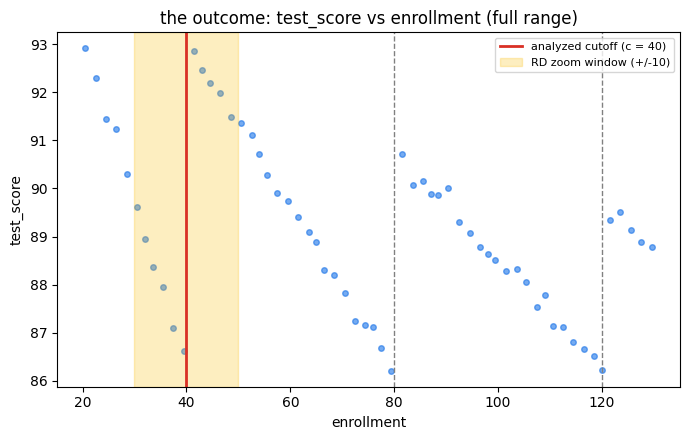

enrollment ranges 20 to 130. Rule cutoffs: 40, 80, 120.
There are other cutoffs (80, 120) -- RD is LOCAL, so we analyze ONE at a time.
The shaded band (30 to 50) is exactly what the next (zoomed) RD plot shows.


In [21]:
_ = rd_overview_plot(data, RUNNING, OUTCOME, CUTOFF, h=BANDWIDTH)

### 1.4 Now zoom into the cutoff - plot first

<div style="background:transparent; padding:10px; border-left:4px solid #1a73e8; border-radius:4px;"><b>Picture before math.</b> This is the shaded band from above, zoomed in. Look for a visible vertical jump at the cutoff before any math - if you cannot see it, no regression will rescue it.</div>

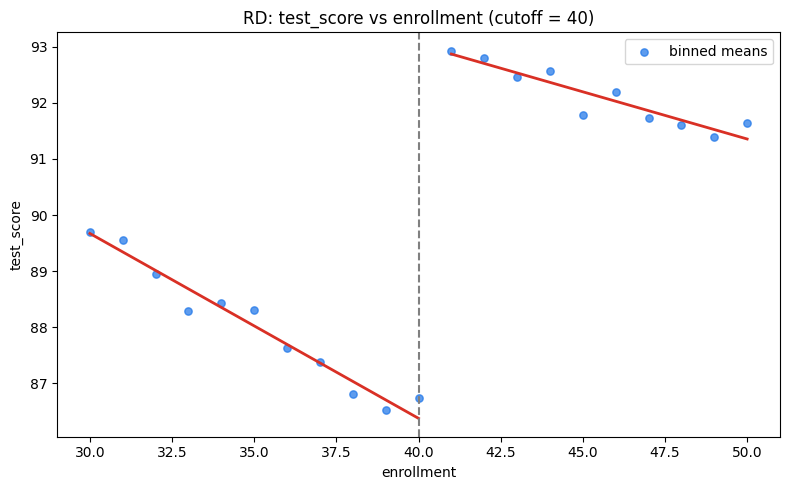


RD jump τ in 'test_score' at enrollment = 40  (two-tailed t-test of H0: τ = 0)
  τ-hat = +6.66   se = 0.18   t = 36.7   p = 0.000
  bandwidth +/-10.0  ->  n = 1106 enrollment values fall within the window and are the ONLY rows used
  (rows outside +/-10.0 of the cutoff are dropped before the regression)


In [22]:
_ = rd_plot(data, RUNNING, OUTCOME, CUTOFF, h=BANDWIDTH)

### 1.5 The RD estimate

We fit two local linear regressions - one on each side of the cutoff - inside the bandwidth. Equivalently, **one** regression with an interaction:

$$Y_i \;=\; \alpha \;+\; \tau\,D_i \;+\; \beta\,(R_i - c) \;+\; \gamma\,D_i\,(R_i - c) \;+\; \varepsilon_i,
\qquad D_i = \mathbf{1}\{R_i > c\}$$

estimated only on grades inside the window $|R_i - c| \le h$.

**where**

- $Y_i$ - outcome (test score)
- $R_i$ - running variable (enrollment);  $c$ - the cutoff (40)
- $D_i = \mathbf{1}\{R_i > c\}$ - treatment indicator: 1 above the cutoff, 0 below
- $\alpha$ - outcome level just **below** the cutoff
- $\boldsymbol{\tau}$ - **the jump at the cutoff. This is the RD estimate** - the number we report and test
- $\beta$ - slope of $Y$ in $R$ just below the cutoff
- $\gamma$ - how that slope *changes* above the cutoff (the interaction lets each side have its own slope)
- $\varepsilon_i$ - error term

We test $H_0:\ \tau = 0$ against $H_1:\ \tau \neq 0$ with a **two-tailed $t$-test**, $\;t = \hat{\tau}\,/\,\operatorname{se}(\hat{\tau})$. The output below prints the **actual regression** - the coefficient on the `above_40` row *is* $\hat{\tau}$.

In [23]:
rd_main_est = rd_estimate(data, OUTCOME, RUNNING, CUTOFF, h=BANDWIDTH)

RD estimate (local linear, two sides, uniform kernel, +/-10.0, n = 1106)
  model:  Y = α + τ*D + β*(R-c) + γ*D*(R-c) + ε      D = 1 if R > c else 0
  table rows:  const = α,  above_40 = τ,  enrollment_minus_40 = β,  above_40_x_enrollment_minus_40 = γ
  --> the coefficient on 'above_40' below IS τ-hat (the jump at the cutoff)

                            OLS Regression Results                            
Dep. Variable:             test_score   R-squared:                       0.701
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     857.1
Date:                Mon, 18 May 2026   Prob (F-statistic):          1.74e-287
Time:                        16:29:29   Log-Likelihood:                -1957.9
No. Observations:                1106   AIC:                             3924.
Df Residuals:                    1102   BIC:                             3944.
Df Model:                           3   

<div style="background:transparent; padding:10px; border-left:4px solid #1a73e8; border-radius:4px;"><b>Read this.</b> The jump (~ +7 test points) is the effect of being in the <b>post-cutoff (small-class) regime</b> - what you read straight off the picture in a <b>sharp</b> RD. The per-student class-size effect (the number that lines up with the IV week) comes in Section 3 via the Wald ratio.</div>

---
## 2. Validity - three non-negotiable checks

<div style="background:transparent; padding:10px; border-left:4px solid #1a73e8; border-radius:4px;"><b>The p-value rule here is the OPPOSITE of a regression</b> - same flip as the matching balance table: you <b>want large p / no jump</b>. A significant jump in any of these is bad for the design.</div>

### 2.1 McCrary density test (no manipulation)

Is the density of the running variable continuous at the cutoff? Bunching on one side means units are gaming the rule.

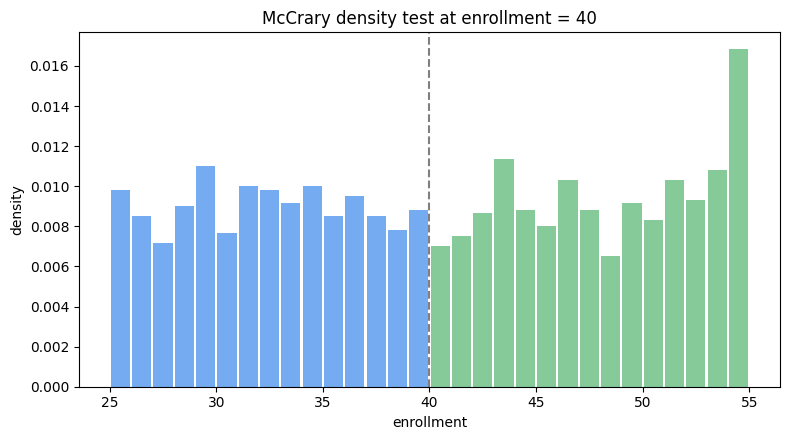

McCrary density test at enrollment = 40
  density just below = 0.00886   just above = 0.00717
  discontinuity = -0.00169   z = -1.37   p = 0.171
>>> p > 0.10: no evidence of manipulation (PASS)


In [24]:
mc = mccrary_test(data, RUNNING, CUTOFF)

### 2.2 Covariate balance at the cutoff

Re-run the RD with each *pre-treatment* covariate as the outcome. None should jump - the matching balance table, localized to the cutoff.

In [25]:
# -- USER INPUTS --------------------------------------------------------
BALANCE_VARS   = ['prior_score', 'pct_disadvantaged']
BALANCE_LABELS = ['Prior-year score', '% disadvantaged']
# -----------------------------------------------------------------------

bal = covariate_balance(data, RUNNING, CUTOFF,
                        BALANCE_VARS, BALANCE_LABELS, h=BANDWIDTH)

Covariate balance at enrollment = 40  (bandwidth +/-10.0); want LARGE p (no jump):

       covariate  jump at cutoff  std err  p-value  verdict
Prior-year score          -0.250    0.732    0.733 balanced
 % disadvantaged           0.628    1.683    0.709 balanced

>>> all covariates balanced at the cutoff (PASS)


### 2.3 Bandwidth sensitivity

Re-estimate at half, the chosen, and double the window. Numbers should wobble (noise) but not flip sign or magnitude (fragility).

In [26]:
bw = bandwidth_sensitivity(data, OUTCOME, RUNNING, CUTOFF,
                           bandwidths=[BANDWIDTH/2, BANDWIDTH, BANDWIDTH*2])

Bandwidth sensitivity for jump in 'test_score' (default h = 10.0):

 bandwidth    n   tau    se  CI low  CI high note
       5.0  567 6.903 0.279   6.356    7.451     
      10.0 1106 6.663 0.182   6.307    7.018     
      20.0 2199 6.723 0.125   6.479    6.968     

>>> same sign, similar magnitude -- robust


### 2.4 (Optional) Placebo cutoffs

Pretend the rule is at a value where there is none. You should find nothing. Each placebo stays in a region with no real cutoff.

In [27]:
pl = placebo_cutoffs(data, OUTCOME, RUNNING, CUTOFF,
                     h=BANDWIDTH, real_cutoffs=CUTOFFS_IN_DATA)

Placebo cutoffs for 'test_score' (real cutoff 40); want NO jump:

 placebo cutoff    tau  p-value verdict
           30.0 -0.066    0.692 OK (~0)
           60.0  0.139    0.432 OK (~0)


---
## 6. Take-home

**On the method**

1. **See the whole picture, then plot the cutoff.** If the jump is not visible, no estimator saves it.
2. **The RD estimate is a local comparison** at the cutoff - LATE *at the cutoff*, nothing more.
3. **Sharp RD** reads the effect off the jump. **Fuzzy RD** rescales by the first stage - and *is* IV using the cutoff as the instrument.
4. **The design lives or dies on the three validity checks.**

**How to read the output**

<div style="background:transparent; padding:10px; border-left:4px solid #1a73e8; border-radius:4px;"><b>1. The jump (tau).</b> The estimated effect - the gap at the cutoff. Sharp: the regime effect. Divide by the first stage for the per-unit effect.</div>

<div style="background:transparent; padding:10px; border-left:4px solid #1a73e8; border-radius:4px;"><b>2. Validity-check p-values - opposite rule.</b> Here you <b>want large p</b>. Small p in a validity check = broken design.</div>

<div style="background:transparent; padding:10px; border-left:4px solid #1a73e8; border-radius:4px;"><b>3. Bandwidth sensitivity.</b> The estimate should keep its sign and rough size across windows.</div>

**Next** - a separate **practice notebook on the MLDA data** (minimum legal drinking age, a single clean cutoff at 21): it is *this* notebook with the Section 1.2 cell re-pointed.

---
## 7. Swapping in your own dataset

This notebook is a true template. To reuse it, edit **only the Section 1.2 USER INPUTS cell**:

1. `data`, `RUNNING`, `OUTCOME`, `CUTOFF` - your columns and cutoff.
2. `BANDWIDTH` - **rescale to your running variable's units** (the row names in the regression table, e.g. `above_40`, follow `CUTOFF`).
3. `CUTOFFS_IN_DATA` - every real cutoff in the data. Single-cutoff design (e.g. MLDA): use `[CUTOFF]`; the bandwidth guard then becomes a no-op automatically.
4. `TREATMENT` / `TREATMENT_CONT` - the treatment columns for Section 3 (set `TREATMENT_CONT = None` if there is no continuous treatment).
5. `BALANCE_VARS` / `BALANCE_LABELS` in Section 2.2 - your *pre-treatment* covariates.

Notes: drop missing values in the columns you use; the sharp-vs-fuzzy comparison (Section 3) needs both a sharp and a fuzzy file - if your design is only one of the two, run only the relevant half; remove `true_effect=` in Section 3.2 for real data (no known truth).